# Longitudinal RSE Burnout Analysis: 2016 – 2022

Tracks the composite **burnout risk** of Research Software Engineers, and the gap between those
in **dedicated RSE groups** vs **embedded RSEs**, across four international survey waves:
2016 (UK-only), 2017 (multi-country), 2018 (international), 2022 (international).

**Data source:** [softwaresaved/RSE_survey_longitudinal](https://github.com/softwaresaved/RSE_survey_longitudinal)

## 1. Import Libraries

In [6]:
import os
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats as sp_stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Libraries loaded.")

Libraries loaded.


## 2. Download Survey Data

Each year's main data file (`{year}_tf.csv`) is fetched from the longitudinal repository and cached locally.

In [7]:
LONG_BASE = "https://raw.githubusercontent.com/softwaresaved/RSE_survey_longitudinal/main"
DATA_DIR  = "data"
os.makedirs(DATA_DIR, exist_ok=True)

YEARS = [2016, 2017, 2018, 2022]

def download(url: str, dest: str) -> str:
    if os.path.exists(dest):
        print(f"  [cached] {dest}")
        return dest
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    with open(dest, "wb") as f:
        f.write(r.content)
    print(f"  [downloaded] {dest}")
    return dest

for year in YEARS:
    url  = f"{LONG_BASE}/{year}/{year}_tf.csv"
    dest = f"{DATA_DIR}/{year}_tf.csv"
    download(url, dest)

print("\nAll data files ready.")

  [cached] data/2016_tf.csv
  [cached] data/2017_tf.csv
  [cached] data/2018_tf.csv
  [cached] data/2022_tf.csv

All data files ready.


## 3. Load and Harmonise Data Across Years

Each year uses slightly different column names and question wordings. We map each year's columns
to a common schema, then concatenate into a single longitudinal DataFrame.

| Common field         | 2016 source            | 2017 source                    | 2018 source       | 2022 source       |
|----------------------|------------------------|--------------------------------|-------------------|-------------------|
| `dedicated_group`    | `currentWork2_0`       | `currentWork2_0`               | `currentWork2_0`  | `currentWork2_0`  |
| `satisfaction`       | *(affSat mean, scaled)*| `likert3[satisgen1]_0`         | `satisGen1_0`     | `satisGen1_0`     |
| `turnover`           | `turnOver3_0`          | `likert1[turnOver3]_0`         | `turnOver3_0`     | `turnOver3_0`     |
| `turnover6`          | `turnOver6_0`          | `likert2[turnOver6]_0`         | `turnOver6_0`     | `turnOver6_0`     |
| `recog_supervisor`   | `affRec3_0`            | `likert2[affRec3]_0`           | `recog1_0`        | `recog1_0`        |

> **Note on 2016 satisfaction:** The 2016 survey used item-level affective satisfaction questions (affSat1–4)
> rather than a single 1–10 rating. We construct a proxy by averaging those four 1–5 Likert items and
> rescaling to 1–10 so it can contribute to the composite burnout score.

In [21]:
# ---------------------------------------------------------------------------
# Agree/disagree Likert mapping — case-insensitive and handles 2016/2018 wording
AGREE_CI = {
    "strongly agree": 5,
    "agree": 4,
    "neither agree nor disagree": 3,
    "neither agree or disagree": 3,   # 2016 / 2018 wording variant
    "disagree": 2,
    "strongly disagree": 1,
}

FREQ_CI = {                            # 2016 turnover text → 1-5 rank
    "never": 1, "rarely": 2, "sometimes": 3, "often": 4, "always": 5,
}

def agree_01(series):
    """Map 5-point text Likert (agree) → 0-1 float. Handles capitalisation variants."""
    raw = series.astype(str).str.strip().str.lower().map(AGREE_CI)
    return pd.to_numeric(raw, errors="coerce").sub(1).div(4)   # (1-5) → 0-1

def leading_int(series):
    """Extract leading integer from strings like '1 (None at all)', '10 (All...)', '8'."""
    cleaned = series.astype(str).str.strip().str.replace('\ufeff', '', regex=False)
    return pd.to_numeric(cleaned.str.extract(r'^(\d+)')[0], errors="coerce")

def freq_text_01(series):
    """Map 2016 text frequency ('Never'/'Sometimes'/'Often') → 0-1."""
    raw = series.astype(str).str.strip().str.lower().map(FREQ_CI)
    return pd.to_numeric(raw, errors="coerce").sub(1).div(4)


def load_2016(path):
    df = pd.read_csv(path, low_memory=False)
    rse_mask = (df["rse16a_0"] == True) | (df["rse16b_0"] == True)
    df = df[rse_mask].copy()

    # Satisfaction: mean of affSat1-4 (1-5 Likert) → 0-1
    affsat_cols = ["affSat1_0", "affSat2_0", "affSat3_0", "affSat4_0"]
    avail = [c for c in affsat_cols if c in df.columns]
    if avail:
        parts = pd.DataFrame({c: agree_01(df[c]) for c in avail})
        df["satisfaction_01"] = parts.mean(axis=1)
    else:
        df["satisfaction_01"] = np.nan

    # Turnover frequency: "Never"/"Sometimes"/"Often" text → 0-1
    df["turnover_01"]  = freq_text_01(df["turnOver3_0"]) if "turnOver3_0" in df.columns else np.nan
    # Turnover willingness: agree/disagree Likert → 0-1
    df["turnover6_01"] = agree_01(df["turnOver6_0"]) if "turnOver6_0" in df.columns else np.nan

    # Recognition: agree/disagree Likert → 0-1
    df["recog_01"] = agree_01(df["affRec3_0"]) if "affRec3_0" in df.columns else np.nan

    # Dedicated group: boolean column
    df["dedicated_group"] = df["currentWork2_0"].map({True: "Yes", False: "No"}) if "currentWork2_0" in df.columns else np.nan

    df["year"]    = 2016
    df["country"] = "United Kingdom"
    return df[["year", "country", "dedicated_group", "satisfaction_01",
               "turnover_01", "turnover6_01", "recog_01"]].copy()


def load_2017(path):
    df = pd.read_csv(path, low_memory=False)
    rse_mask = (df.get("rse1_0", pd.Series(False, index=df.index)) == True) | \
               (df.get("rse4de_0", pd.Series(False, index=df.index)) == True)
    df = df[rse_mask].copy()

    def gc(name):
        return df[name] if name in df.columns else pd.Series(np.nan, index=df.index)

    # Satisfaction: 1-10 numeric string → 0-1
    sat_raw = leading_int(gc("likert3[satisgen1]_0"))
    df["satisfaction_01"] = (sat_raw - 1) / 9

    # Turnover frequency: mixed — numeric 1-10 strings OR text "Never"/"Sometimes"/"Often"
    to_raw = gc("likert1[turnOver3]_0")
    to_num = leading_int(to_raw)
    to_num_01 = (to_num - 1) / 9
    to_txt_01 = freq_text_01(to_raw)
    df["turnover_01"] = to_num_01.where(to_num.notna(), to_txt_01)
    # Turnover willingness: agree/disagree text → 0-1
    df["turnover6_01"] = agree_01(gc("likert2[turnOver6]_0"))

    # Recognition: agree/disagree text → 0-1
    df["recog_01"] = agree_01(gc("likert2[affRec3]_0"))

    df["dedicated_group"] = gc("currentWork2_0").map({True: "Yes", False: "No"})
    df["year"]    = 2017
    df["country"] = gc("socio1_0")
    return df[["year", "country", "dedicated_group", "satisfaction_01",
               "turnover_01", "turnover6_01", "recog_01"]].copy()


def load_year(path, year):
    df = pd.read_csv(path, low_memory=False)
    rse_mask = (df.get("rse1_0", pd.Series(False, index=df.index)) == True) | \
               (df.get("rse4de_0", pd.Series(False, index=df.index)) == True)
    df = df[rse_mask].copy()

    def gc(name):
        return df[name] if name in df.columns else pd.Series(np.nan, index=df.index)

    # Satisfaction: "8"/"10 - Completely satisfied" etc. → leading int → 0-1
    sat_raw = leading_int(gc("satisGen1_0"))
    df["satisfaction_01"] = (sat_raw - 1) / 9

    # Turnover frequency: "1 (None at all)"/"10 (All the time)"/"2"... → leading int → 0-1
    to_raw = leading_int(gc("turnOver3_0"))
    df["turnover_01"] = (to_raw - 1) / 9
    # Turnover willingness: agree/disagree text → 0-1
    df["turnover6_01"] = agree_01(gc("turnOver6_0"))

    # Recognition: agree/disagree text → 0-1
    df["recog_01"] = agree_01(gc("recog1_0"))

    df["dedicated_group"] = gc("currentWork2_0").map({True: "Yes", False: "No"})
    df["year"]    = year
    df["country"] = gc("socio1_0")
    return df[["year", "country", "dedicated_group", "satisfaction_01",
               "turnover_01", "turnover6_01", "recog_01"]].copy()


raw = {
    2016: load_2016(f"{DATA_DIR}/2016_tf.csv"),
    2017: load_2017(f"{DATA_DIR}/2017_tf.csv"),
    2018: load_year(f"{DATA_DIR}/2018_tf.csv", 2018),
    2022: load_year(f"{DATA_DIR}/2022_tf.csv", 2022),
}

panel = pd.concat(raw.values(), ignore_index=True)

print(f"Panel shape: {panel.shape}")
print("\nRSE respondents per year:")
for y in YEARS:
    n = (panel["year"] == y).sum()
    g = panel[panel["year"] == y]["dedicated_group"].value_counts(dropna=False).to_dict()
    print(f"  {y}: n={n}  dedicated={g.get('Yes',0)}  embedded={g.get('No',0)}")

print("\nComponent coverage per year (% non-missing):")
for y in YEARS:
    sub = panel[panel["year"] == y]
    row = {c: f"{sub[c].notna().mean()*100:.0f}%" for c in ["satisfaction_01", "turnover_01", "turnover6_01", "recog_01"]}
    print(f"  {y}: {row}")

Panel shape: (3077, 7)

RSE respondents per year:
  2016: n=235  dedicated=149  embedded=86
  2017: n=921  dedicated=291  embedded=281
  2018: n=964  dedicated=438  embedded=433
  2022: n=957  dedicated=441  embedded=385

Component coverage per year (% non-missing):
  2016: {'satisfaction_01': '100%', 'turnover_01': '100%', 'turnover6_01': '100%', 'recog_01': '100%'}
  2017: {'satisfaction_01': '76%', 'turnover_01': '69%', 'turnover6_01': '67%', 'recog_01': '75%'}
  2018: {'satisfaction_01': '86%', 'turnover_01': '79%', 'turnover6_01': '77%', 'recog_01': '80%'}
  2022: {'satisfaction_01': '76%', 'turnover_01': '75%', 'turnover6_01': '73%', 'recog_01': '80%'}


## 4. Exploratory Data Analysis

In [22]:
print("=== Dedicated Group Distribution Per Year ===")
grp = panel.groupby("year")["dedicated_group"].value_counts(normalize=True).mul(100).unstack(fill_value=0)
print(grp.round(1).to_string())

print("\n=== Missingness in key burnout variables by year ===")
VARS = ["satisfaction_01", "turnover_01", "turnover6_01", "recog_01"]
miss = panel.groupby("year")[VARS].apply(lambda x: x.isna().mean() * 100)
print(miss.round(1).to_string())

print("\n=== Mean component values per year (all RSEs) ===")
means = panel.groupby("year")[VARS].mean()
print(means.round(3).to_string())

=== Dedicated Group Distribution Per Year ===
dedicated_group    No   Yes
year                       
2016             36.6  63.4
2017             49.1  50.9
2018             49.7  50.3
2022             46.6  53.4

=== Missingness in key burnout variables by year ===
      satisfaction_01  turnover_01  turnover6_01  recog_01
year                                                      
2016              0.0          0.4           0.4       0.4
2017             23.6         31.2          32.9      24.5
2018             14.2         21.5          22.5      20.3
2022             24.5         24.9          26.5      20.2

=== Mean component values per year (all RSEs) ===
      satisfaction_01  turnover_01  turnover6_01  recog_01
year                                                      
2016            0.659        0.395         0.406     0.618
2017            0.649        0.370         0.377     0.637
2018            0.653        0.374         0.402     0.759
2022            0.647        0.3

## 5. Feature Engineering

Compute a composite `burnout_risk` score (0–1) from four components, all normalised to a common scale:

| Component | Raw scale | Normalised (higher = more risk) |
|---|---|---|
| `satisfaction` | 1–10 (2016 proxy: affSat1-4 mean) | `1 – satisfaction_01` |
| `turnover` | 1–10 numeric / text (Never→Always) | `turnover_01` |
| `recog_supervisor` | 1–5 (Strongly disagree→Strongly agree) | `1 – recog_01` |
| `turnover6` | 1–5 (Strongly disagree→Strongly agree) | `turnover6_01` (no inversion) |

`burnout_risk` = row-wise mean of available (non-NaN) normalised components.

In [23]:
# Components (all already 0-1, higher = more of the underlying dimension)
# For burnout_risk we invert satisfaction and recognition (high sat/recog = low risk)
panel["c_low_sat"]   = 1 - panel["satisfaction_01"]   # low satisfaction
panel["c_turnover"]  = panel["turnover_01"]            # high turnover intent (freq)
panel["c_low_recog"] = 1 - panel["recog_01"]           # low recognition
panel["c_turnover6"] = panel["turnover6_01"]           # willingness to accept new job

COMPONENTS = ["c_low_sat", "c_turnover", "c_low_recog", "c_turnover6"]

# Row-wise mean ignoring NaN (missing components don't discard the row)
panel["burnout_risk"] = panel[COMPONENTS].mean(axis=1)

print("burnout_risk stats:")
print(panel["burnout_risk"].describe().round(3))

print("\nComponent coverage per year (% non-missing):")
cov = panel.groupby("year")[COMPONENTS + ["burnout_risk"]].apply(lambda x: x.notna().mean() * 100)
print(cov.round(1).to_string())

burnout_risk stats:
count    2570.000
mean        0.339
std         0.204
min         0.000
25%         0.181
50%         0.315
75%         0.458
max         1.056
Name: burnout_risk, dtype: float64

Component coverage per year (% non-missing):
      c_low_sat  c_turnover  c_low_recog  c_turnover6  burnout_risk
year                                                               
2016      100.0        99.6         99.6         99.6         100.0
2017       76.4        68.8         75.5         67.1          77.4
2018       85.8        78.5         79.7         77.5          86.4
2022       75.5        75.1         79.8         73.5          82.4


## 6. Longitudinal Analysis: Dedicated vs Embedded RSEs

Within each survey year, compare `burnout_risk` between dedicated and embedded RSEs using:
- **Mann-Whitney U** (non-parametric, two-tailed)
- **Cohen's d** (effect size, pooled SD)
- Bootstrap 95% CI on the mean difference

In [24]:
from scipy import stats as sp_stats

RNG = np.random.default_rng(42)
N_BOOT = 2000

def cohens_d(a, b):
    """Pooled Cohen's d (positive = a > b)."""
    na, nb = len(a), len(b)
    pooled_sd = np.sqrt(((na - 1) * a.std(ddof=1)**2 + (nb - 1) * b.std(ddof=1)**2) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_sd if pooled_sd > 0 else np.nan

def bootstrap_ci(a, b, n_boot=N_BOOT, rng=RNG):
    """Bootstrap 95% CI on mean(b) - mean(a) difference (embedded - dedicated)."""
    diffs = []
    for _ in range(n_boot):
        da = rng.choice(a, size=len(a), replace=True).mean()
        db = rng.choice(b, size=len(b), replace=True).mean()
        diffs.append(db - da)
    return np.percentile(diffs, [2.5, 97.5])

results = []
for year in YEARS:
    sub = panel[(panel["year"] == year) & (panel["dedicated_group"].isin(["Yes", "No"]))].copy()
    ded = sub[sub["dedicated_group"] == "Yes"]["burnout_risk"].dropna().values
    emb = sub[sub["dedicated_group"] == "No"]["burnout_risk"].dropna().values

    if len(ded) < 10 or len(emb) < 10:
        print(f"{year}: insufficient data (ded={len(ded)}, emb={len(emb)})")
        continue

    stat, pval = sp_stats.mannwhitneyu(ded, emb, alternative="two-sided")
    d = cohens_d(emb, ded)  # positive = embedded higher risk
    ci_lo, ci_hi = bootstrap_ci(ded, emb)

    results.append({
        "year": year,
        "n_dedicated": len(ded),
        "n_embedded": len(emb),
        "mean_dedicated": ded.mean(),
        "mean_embedded": emb.mean(),
        "diff_emb_minus_ded": emb.mean() - ded.mean(),
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
        "cohen_d": d,
        "p_value": pval,
    })

results_df = pd.DataFrame(results)
results_df["sig"] = results_df["p_value"].apply(
    lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
)

display_cols = ["year", "n_dedicated", "n_embedded",
                "mean_dedicated", "mean_embedded", "diff_emb_minus_ded",
                "ci_lo", "ci_hi", "cohen_d", "p_value", "sig"]
print(results_df[display_cols].to_string(index=False, float_format="{:.3f}".format))

 year  n_dedicated  n_embedded  mean_dedicated  mean_embedded  diff_emb_minus_ded  ci_lo  ci_hi  cohen_d  p_value sig
 2016          149          86           0.375          0.392               0.017 -0.032  0.067    0.093    0.565  ns
 2017          269         255           0.330          0.391               0.060  0.027  0.094    0.304    0.001  **
 2018          420         413           0.307          0.368               0.061  0.033  0.089    0.293    0.000 ***
 2022          423         366           0.279          0.342               0.063  0.035  0.092    0.313    0.000 ***


## 7. Visualisations

**Fig 1** – Mean burnout risk over time for dedicated vs embedded RSEs, with 95% bootstrap CI.  
**Fig 2** – Effect size (Cohen's d) per year with significance markers.  
**Fig 3** – Year-by-year component-level gap heatmap (embedded minus dedicated, z-scored).

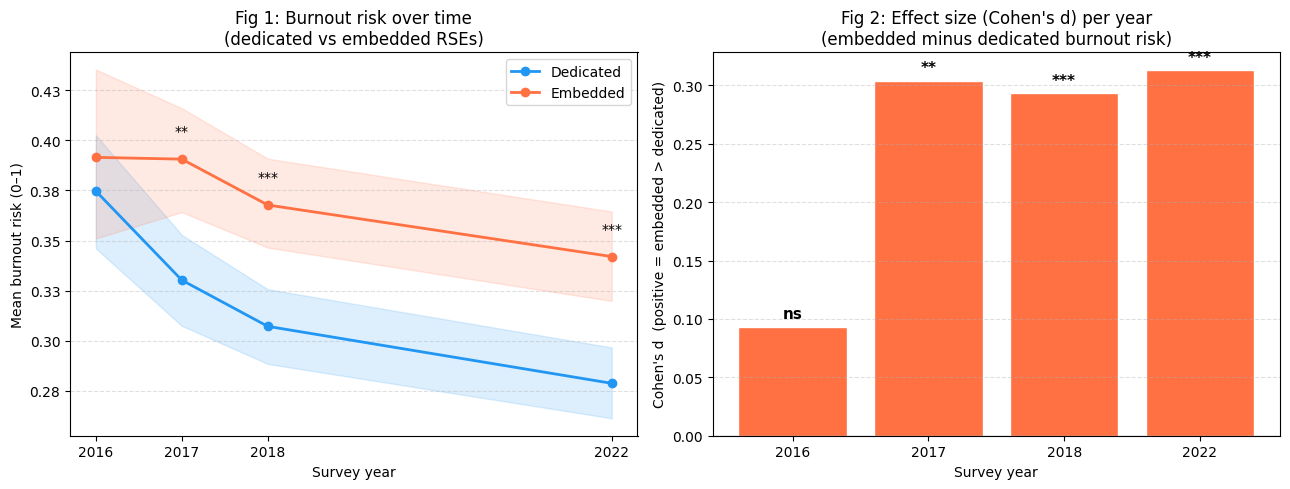

Saved burnout_longitudinal_fig1_fig2.png


In [25]:
import matplotlib.ticker as mticker

DEDICATED_COLOR = "#2196F3"
EMBEDDED_COLOR  = "#FF7043"
FIG_DIR = "."

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Fig 1: Trend lines with CI bands ---
ax1 = axes[0]
years_plot = results_df["year"].values

for grp_label, color, mean_col, ci_col in [
    ("Dedicated", DEDICATED_COLOR, "mean_dedicated", None),
    ("Embedded",  EMBEDDED_COLOR,  "mean_embedded",  None),
]:
    means = results_df[mean_col].values
    ax1.plot(years_plot, means, marker="o", label=grp_label, color=color, linewidth=2)

# CI band on the difference → show individual CIs via bootstrap stored in results_df
# Re-derive per-group bootstrap CIs quickly
for grp_label, color, grp_val, mean_col in [
    ("Dedicated", DEDICATED_COLOR, "Yes", "mean_dedicated"),
    ("Embedded",  EMBEDDED_COLOR,  "No",  "mean_embedded"),
]:
    lo_vals, hi_vals = [], []
    for year in years_plot:
        sub = panel[(panel["year"] == year) & (panel["dedicated_group"] == grp_val)]["burnout_risk"].dropna().values
        lo, hi = np.percentile(
            [RNG.choice(sub, size=len(sub), replace=True).mean() for _ in range(N_BOOT)],
            [2.5, 97.5]
        )
        lo_vals.append(lo); hi_vals.append(hi)
    ax1.fill_between(years_plot, lo_vals, hi_vals, alpha=0.15, color=color)

ax1.set_xlabel("Survey year")
ax1.set_ylabel("Mean burnout risk (0–1)")
ax1.set_title("Fig 1: Burnout risk over time\n(dedicated vs embedded RSEs)")
ax1.set_xticks(years_plot)
ax1.legend()
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# Add significance markers above the embedded line
for _, row in results_df.iterrows():
    if row["sig"] != "ns":
        ax1.annotate(row["sig"], xy=(row["year"], row["mean_embedded"] + 0.012),
                     ha="center", fontsize=10, color="black")

# --- Fig 2: Cohen's d per year ---
ax2 = axes[1]
bar_colors = [DEDICATED_COLOR if d < 0 else EMBEDDED_COLOR for d in results_df["cohen_d"]]
bars = ax2.bar(results_df["year"].astype(str), results_df["cohen_d"], color=bar_colors, edgecolor="white")

# Error bars from CI (on diff) converted to rough d scale — use p-value annotation instead
for bar, (_, row) in zip(bars, results_df.iterrows()):
    y_pos = row["cohen_d"] + (0.005 if row["cohen_d"] >= 0 else -0.015)
    ax2.text(bar.get_x() + bar.get_width() / 2, y_pos, row["sig"],
             ha="center", va="bottom", fontsize=11, fontweight="bold")

ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xlabel("Survey year")
ax2.set_ylabel("Cohen's d  (positive = embedded > dedicated)")
ax2.set_title("Fig 2: Effect size (Cohen's d) per year\n(embedded minus dedicated burnout risk)")
ax2.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/burnout_longitudinal_fig1_fig2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved burnout_longitudinal_fig1_fig2.png")

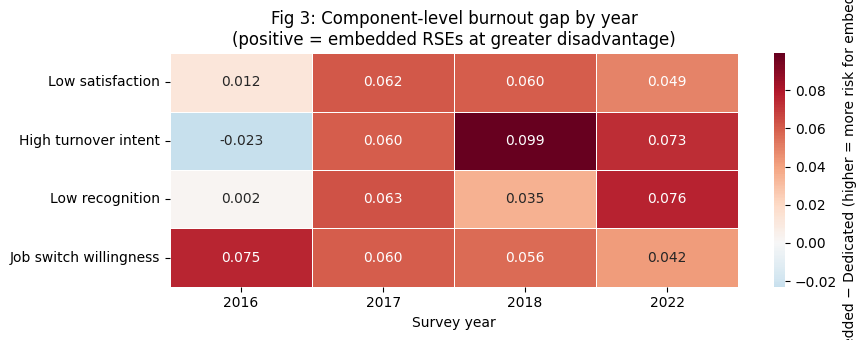

Saved burnout_longitudinal_fig3_heatmap.png


In [26]:
# Fig 3: Component-level gap heatmap (embedded mean minus dedicated mean)
COMP_LABELS = {
    "c_low_sat":    "Low satisfaction",
    "c_turnover":   "High turnover intent",
    "c_low_recog":  "Low recognition",
    "c_turnover6":  "Job switch willingness",
}

gap_rows = []
for year in YEARS:
    sub = panel[(panel["year"] == year) & (panel["dedicated_group"].isin(["Yes", "No"]))]
    row = {"year": year}
    for comp, label in COMP_LABELS.items():
        ded_mean = sub[sub["dedicated_group"] == "Yes"][comp].mean()
        emb_mean = sub[sub["dedicated_group"] == "No"][comp].mean()
        row[label] = emb_mean - ded_mean
    gap_rows.append(row)

gap_df = pd.DataFrame(gap_rows).set_index("year")

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.heatmap(
    gap_df.T, annot=True, fmt=".3f", center=0,
    cmap="RdBu_r", linewidths=0.5,
    cbar_kws={"label": "Embedded − Dedicated (higher = more risk for embedded)"},
    ax=ax
)
ax.set_title("Fig 3: Component-level burnout gap by year\n(positive = embedded RSEs at greater disadvantage)")
ax.set_xlabel("Survey year")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/burnout_longitudinal_fig3_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved burnout_longitudinal_fig3_heatmap.png")